# CreditScope Stage 3R: semantically remediated baseline

UCI warns that the older Statlog coding information contains serious semantic errors. Stage 3R keeps ID 144 as the modelling data and uses ID 573 for corrected semantic guidance. Original Stage 3 outputs are preserved as historical evidence.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from creditscope.stage3 import generate_stage3_artifacts

run_summary = generate_stage3_artifacts(PROJECT_ROOT)
run_summary

{'stage': '3R semantic remediation',
 'authoritative_baseline': True,
 'legacy_results_preserved': True,
 'development_rows_used_for_cv': 800,
 'final_test_rows_isolated': 200,
 'predictive_feature_count': 17,
 'numeric_feature_count': 2,
 'one_hot_feature_count': 15,
 'audit_attribute_count': 3,
 'cv_folds': 5,
 'random_state': 42,
 'default_threshold': 0.5,
 'convergence_warnings': 0,
 'figures_created': 4,
 'final_test_performance_evaluated': False,
 'test_rows_used_for_fitting': False,
 'hyperparameter_tuning_performed': False,
 'threshold_optimization_performed': False,
 'resampling_performed': False,
 'class_weight': None,
 'models_trained': ['DummyClassifier', 'LogisticRegression'],
 'split_manifest_sha256': '32fb4c9ac2cdb358e3bffd145cd97e1a393c14946888d46212d0b395523e99af'}

## What changed and what remained fixed

Only `duration_months` and transformed `credit_amount` remain numeric and standardized. The other 15 predictive fields are one-hot encoded, including corrected ordinal/discretized variables. The locked split, development rows, CV folds, models, hyperparameters, class weighting, threshold 0.50, and 5:1 cost are unchanged. Audit-only attributes remain excluded.

In [2]:
features = pd.read_csv(PROJECT_ROOT / 'reports/stage3_remediated/feature_set_summary.csv')
display(features)
display(Markdown((PROJECT_ROOT / 'docs/statlog_semantics_audit.md').read_text(encoding='utf-8')))

,feature,role,feature_type,baseline_encoding,included_in_baseline_prediction
0,duration_months,predictive,continuous/quantitative,median imputation then standard scaling,True
1,credit_amount,predictive,continuous/quantitative,median imputation then standard scaling,True
2,checking_account_status,predictive,categorical or discretized/ordinal,most-frequent imputation then one-hot encoding,True
3,credit_history,predictive,categorical or discretized/ordinal,most-frequent imputation then one-hot encoding,True
4,purpose,predictive,categorical or discretized/ordinal,most-frequent imputation then one-hot encoding,True
5,savings_account_status,predictive,categorical or discretized/ordinal,most-frequent imputation then one-hot encoding,True
6,employment_duration,predictive,categorical or discretized/ordinal,most-frequent imputation then one-hot encoding,True
7,installment_rate_percent,predictive,categorical or discretized/ordinal,most-frequent imputation then one-hot encoding,True
8,other_debtors_guarantors,predictive,categorical or discretized/ordinal,most-frequent imputation then one-hot encoding,True
9,residence_duration,predictive,categorical or discretized/ordinal,most-frequent imputation then one-hot encoding,True


# Statlog German Credit semantic audit

Stage 3A audit date: 2026-09-11.

This audit changes no dataset, split, preprocessing implementation, model,
prediction, threshold, or Stage 3 result. It compares the existing CreditScope
representation with UCI's corrected semantic reference before Stage 4.

## Authoritative references and retrieval limits

- UCI [Statlog (German Credit Data), dataset 144](https://archive.ics.uci.edu/dataset/144/statloggermancreditdata),
  DOI [10.24432/C5NC77](https://doi.org/10.24432/C5NC77). Donated
  1994-11-16; page retrieved 2026-09-11.
- UCI [South German Credit, dataset 573](https://archive.ics.uci.edu/dataset/573/south%2Bgerman%2Bcredit%2Bupdate),
  DOI [10.24432/C5QG88](https://doi.org/10.24432/C5QG88). Donated
  2020-06-19; page retrieved 2026-09-11.

UCI describes ID 573 as a correction and background enhancement based on a
representation of the same German credit data. Its page warns that the older
Statlog coding information contained severe errors. The official pages and their
variable descriptions were retrieved. The ID 573 ZIP was reachable but could
not be decoded by the web retrieval service, while direct runtime network access
was blocked. Consequently, the accompanying `codetable.txt`, R reader, and ASCII
data were not independently parsed. Exact numeric code translation and row-level
equivalence are therefore not claimed.

## Feature-by-feature conclusion

The machine-readable 20-row comparison is
`reports/stage3a_semantics_comparison.csv`. It has one unique row per current
CreditScope feature, no blank fields, and preserves schema order.

| CreditScope feature | Corrected ID 573 meaning/type | Stage 3 type | Recommendation | Change? |
|---|---|---|---|---|
| `checking_account_status` | debtor's checking-account status; categorical | nominal | retain one-hot; no-account is substantive | no |
| `duration_months` | credit duration in months; quantitative | numerical | retain numeric scaling | no |
| `credit_history` | compliance with previous or concurrent credit contracts; categorical | nominal | retain one-hot; document clarified scope | no |
| `purpose` | purpose for which credit is needed; categorical | nominal | retain one-hot | no |
| `credit_amount` | DM amount after an unknown monotonic transformation; quantitative | numerical | retain numeric scaling; correct interpretation | no preprocessing change |
| `savings_account_status` | debtor's savings; categorical | nominal | retain one-hot; unknown/no-account is substantive | no |
| `employment_duration` | current-employer duration; ordinal discretization | ordinal | one-hot for baseline LR | yes |
| `installment_rate_percent` | installment-rate band; ordinal discretization | numerical | one-hot for baseline LR | yes |
| `personal_status_sex` | compound category from which sex cannot be recovered | audit-only nominal | retain raw only as limited audit attribute | no predictive change |
| `other_debtors_guarantors` | another debtor or guarantor; categorical | nominal | retain one-hot | no |
| `residence_duration` | years at present residence; ordinal discretization | numerical | one-hot for baseline LR | yes |
| `property` | most valuable property, highest applicable code; ordinal | nominal | retain conservative one-hot; fix documentation | no |
| `age_years` | age in years; quantitative | audit-only numeric | retain audit-only | no predictive change |
| `other_installment_plans` | plans from providers other than lending bank; categorical | nominal | retain one-hot | no |
| `housing` | housing type; categorical | nominal | retain one-hot | no |
| `existing_credits_count` | current/past bank-credit count including current credit; ordinal discretization | numerical | one-hot for baseline LR | yes |
| `job` | job quality; ordinal | ordinal | one-hot for baseline LR | yes |
| `dependents_count` | financially dependent persons; binary discretization | numerical | binary indicator or one-hot | yes |
| `telephone` | registered landline; binary and historically specific | nominal | retain one-hot; flag proxy/transportability risk | no |
| `foreign_worker` | foreign-worker indicator; binary | audit-only nominal | retain audit-only | no predictive change |

### Material semantic corrections

- `credit_amount` must not be presented as an untouched contractual amount. UCI
  says it is denominated in DM but was subjected to an unknown monotonic
  transformation.
- `employment_duration`, `installment_rate_percent`, `residence_duration`, and
  `existing_credits_count` are discretized ordered variables. Their stored codes
  do not establish equal distances.
- `existing_credits_count` includes the current credit and credits the debtor
  has or had at the bank; UCI says the original values are unavailable.
- `dependents_count` is binary/discretized rather than a general count.
- `property` is the most valuable applicable property, using the highest
  applicable code, rather than four unrelated ownership labels.
- `job` represents job quality. Order is supported, but equal step sizes are not.
- `personal_status_sex` does not permit reliable reconstruction of sex. UCI says
  one code combines male singles and female non-singles, and female widows are
  not cleanly covered by the female categories.
- `credit_history` concerns compliance with previous or concurrent contracts.
- ID 573 describes the target as whether the contract was complied with (good)
  or not (bad). CreditScope must retain good/bad credit-risk terminology rather
  than equating the target with an observed default event.

## Encoding implications

For Logistic Regression, using an ordinal integer as one column imposes a single
linear change in log odds for each adjacent code step. Order alone does not
justify equal spacing or a constant effect. One-hot encoding is the conservative
baseline for the six affected predictors because it allows level-specific
associations. It uses more parameters but avoids an unsupported functional form.

Tree models do not impose a linear coefficient, but an ordinal integer still
restricts splits to contiguous portions of the chosen order. One-hot encoding
permits more flexible groupings at the cost of dimensionality. Later tree work
may compare these encodings through development-only sensitivity analysis, but
no tree model is trained in this audit.

## Category-code findings and limitations

ID 144 supplies symbolic `Axx` labels. ID 573 uses corrected integer coding and
refers to its code table and R reader for detailed labels. Because those official
attachments could not be parsed here, this audit does not assert a complete
code-to-code crosswalk, reordered code values, or cell-level identity.

The accessible official descriptions nevertheless establish material differences:

- the Statlog `personal_status_sex` labels cannot be used to derive a reliable
  standalone sex attribute;
- property is an ordered maximum-property construction;
- employment duration, installment rate, residence duration, number of credits,
  and dependents are bands/discretizations rather than raw measurements; and
- no-account, unknown/no-savings, and no-property values remain substantive
  categories, not missing data.

## Dataset-equivalence assessment

Both UCI pages report 1,000 observations and a 700/300 good/bad balance. ID 573
describes a 1973–1975 stratified sample of actual credits with bad credits heavily
oversampled, and calls itself a corrected representation of the same data.
Target meaning is compatible at the good/bad level. The accessible page does not
establish the exact numeric target-code mapping needed for a cell comparison.

Matching dimensions, class counts, and UCI's “same data” description support
shared lineage, but do not prove row order or predictor equivalence. Because the
official ID 573 files could not be parsed, predictor equivalence after documented
recoding and any irreconcilable cell differences remain **not verified**.

## Project data policy

**Recommendation: option B.** Continue using ID 144 as the modelling dataset,
while treating ID 573 as the authoritative correction and clarification source
for feature semantics. Do not silently replace the raw data. Migration to ID 573
is not currently justified because exact code and row equivalence could not be
verified; it should be reconsidered only after retrieving and hashing the official
ID 573 files and constructing a defensible crosswalk.

## Effect on Stage 3

The split remains valid as a deterministic partition of the unchanged ID 144
rows. The Stage 3 implementation is reproducible, but its feature representation
is not the preferred corrected-semantics Logistic Regression baseline.

Stage 3R subsequently completed the authorized remediation without changing the
split. Original results are preserved under
`reports/stage3_legacy_pre_semantic_audit/`. Remediated metrics, coefficients,
figures, and the before/after comparison are under
`reports/stage3_remediated/`, which is authoritative for future comparison.
The executed `notebooks/03_baseline_modelling.ipynb` tells the Stage 3R story.

## Responsible-AI implications

The corrected source strengthens the project's limitations: the sample is old,
bad risks were oversampled, monetary values were transformed, and several inputs
are coarse socioeconomic bands. A 1970s registered landline is particularly weak
for modern transportability. Most importantly, `personal_status_sex` cannot
support a defensible sex-based fairness conclusion. It should remain excluded
from prediction and retained only as a problematic compound audit attribute with
that limitation made explicit.


## Dummy and Logistic Regression development-only results

Both results use aligned out-of-fold predictions from the same five development folds. Accuracy is secondary because the all-good dummy already reaches 70%.

In [3]:
results = pd.read_csv(PROJECT_ROOT / 'reports/stage3_remediated/baseline_comparison.csv')
folds = pd.read_csv(PROJECT_ROOT / 'reports/stage3_remediated/cv_metric_summary.csv')
cost = pd.read_csv(PROJECT_ROOT / 'reports/stage3_remediated/cost_baseline.csv')
display(results)
display(folds)
display(cost)

,model,evaluation_population,threshold,roc_auc,average_precision,precision_bad_credit_risk,recall_bad_credit_risk,f1_bad_credit_risk,balanced_accuracy,brier_score,accuracy,true_negative,false_positive,false_negative,true_positive,false_negative_cost,false_positive_cost,total_cost,average_cost
0,Dummy prior,development out-of-fold predictions,0.5,0.500000,0.300000,0.000000,0.000000,0.000000,0.500000,0.210000,0.700,560,0,240,0,5,1,1200,1.50
1,Logistic Regression,development out-of-fold predictions,0.5,0.762954,0.571027,0.575269,0.445833,0.502347,0.652381,0.176217,0.735,481,79,133,107,5,1,744,0.93


,model,metric,fold_mean,fold_std
0,Dummy prior,roc_auc,0.500000,0.000000
1,Dummy prior,average_precision,0.300000,0.000000
2,Dummy prior,precision_bad_credit_risk,0.000000,0.000000
3,Dummy prior,recall_bad_credit_risk,0.000000,0.000000
4,Dummy prior,f1_bad_credit_risk,0.000000,0.000000
5,Dummy prior,balanced_accuracy,0.500000,0.000000
6,Dummy prior,brier_score,0.210000,0.000000
7,Dummy prior,accuracy,0.700000,0.000000
8,Dummy prior,default_threshold_total_cost,240.000000,0.000000
9,Dummy prior,default_threshold_average_cost,1.500000,0.000000


,model,threshold,true_negative,false_positive,false_negative,true_positive,false_negative_cost,false_positive_cost,total_cost,average_cost
0,Dummy prior,0.5,560,0,240,0,5,1,1200,1.50
1,Logistic Regression,0.5,481,79,133,107,5,1,744,0.93


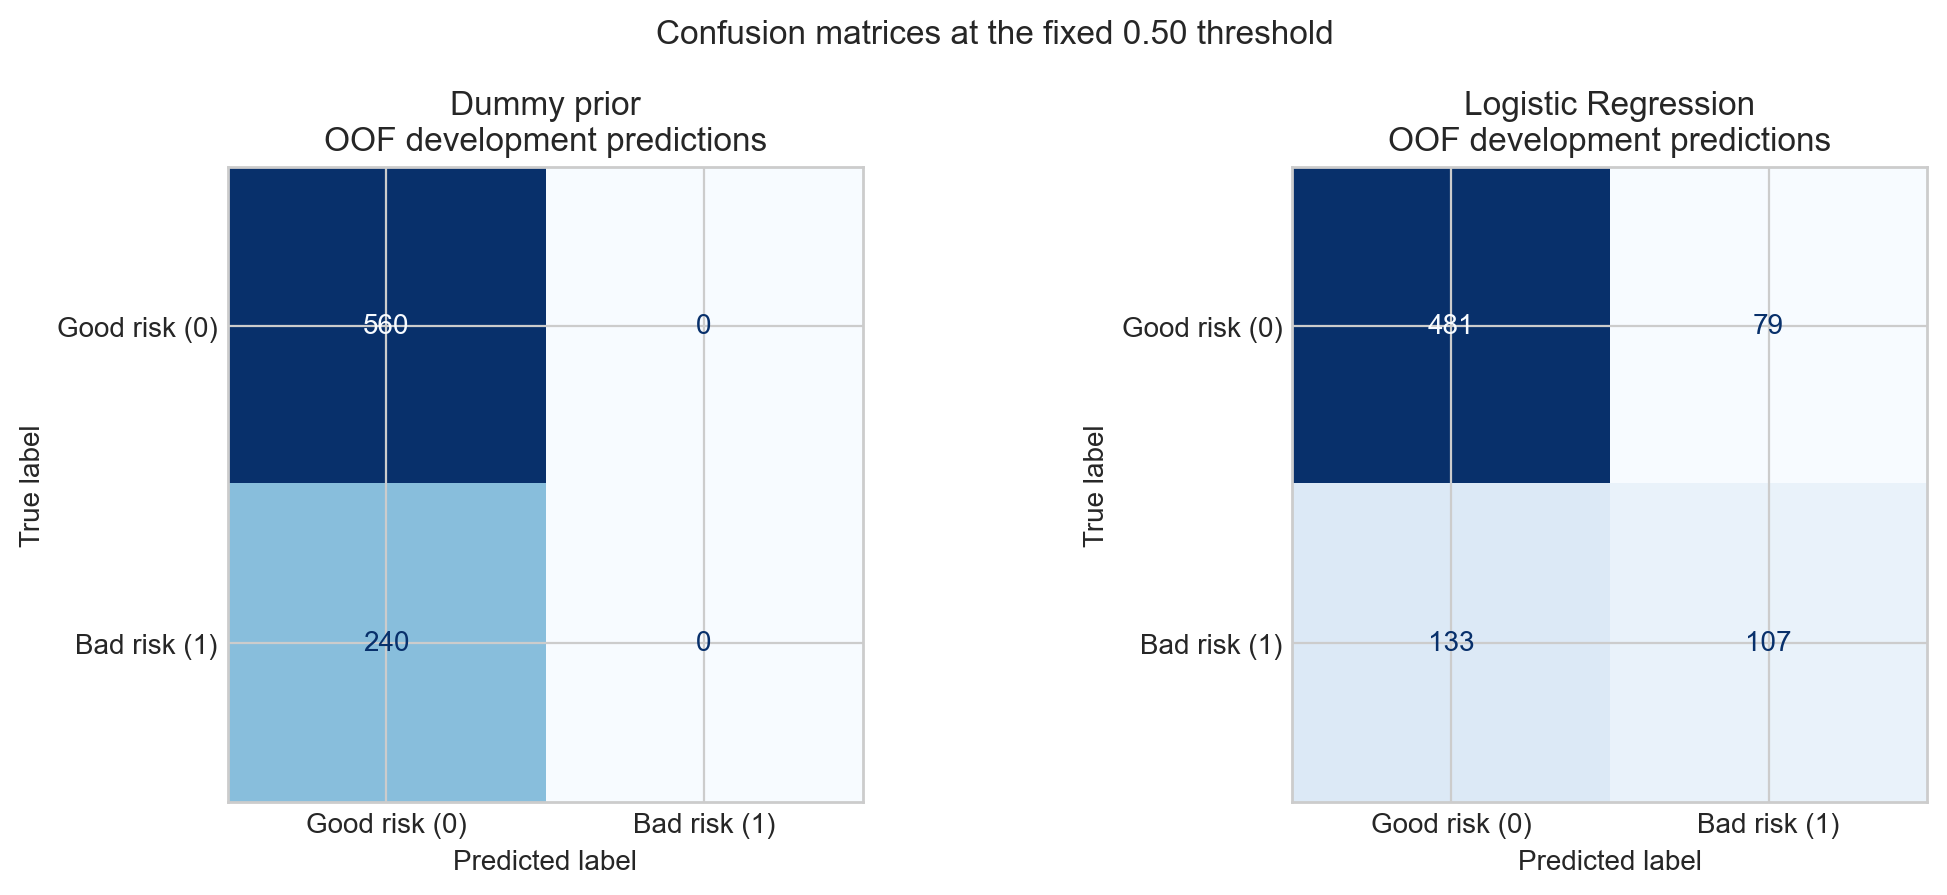

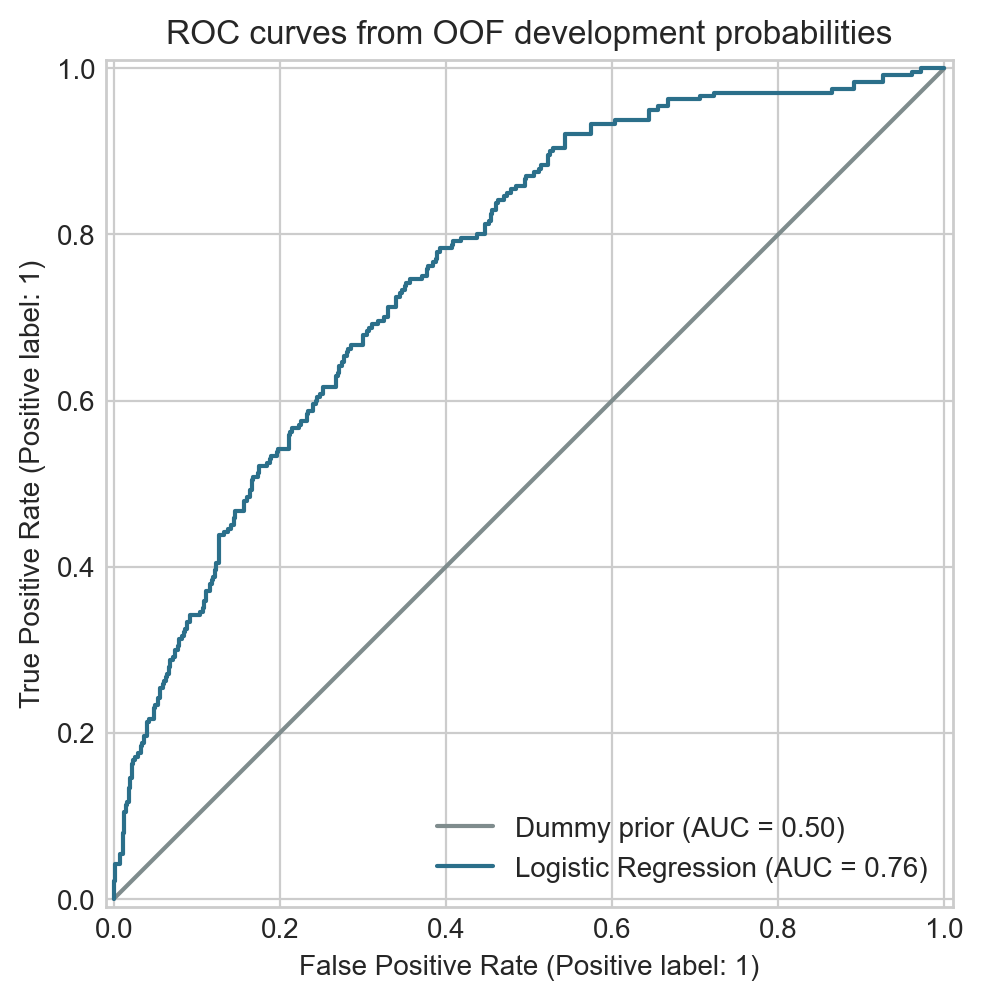

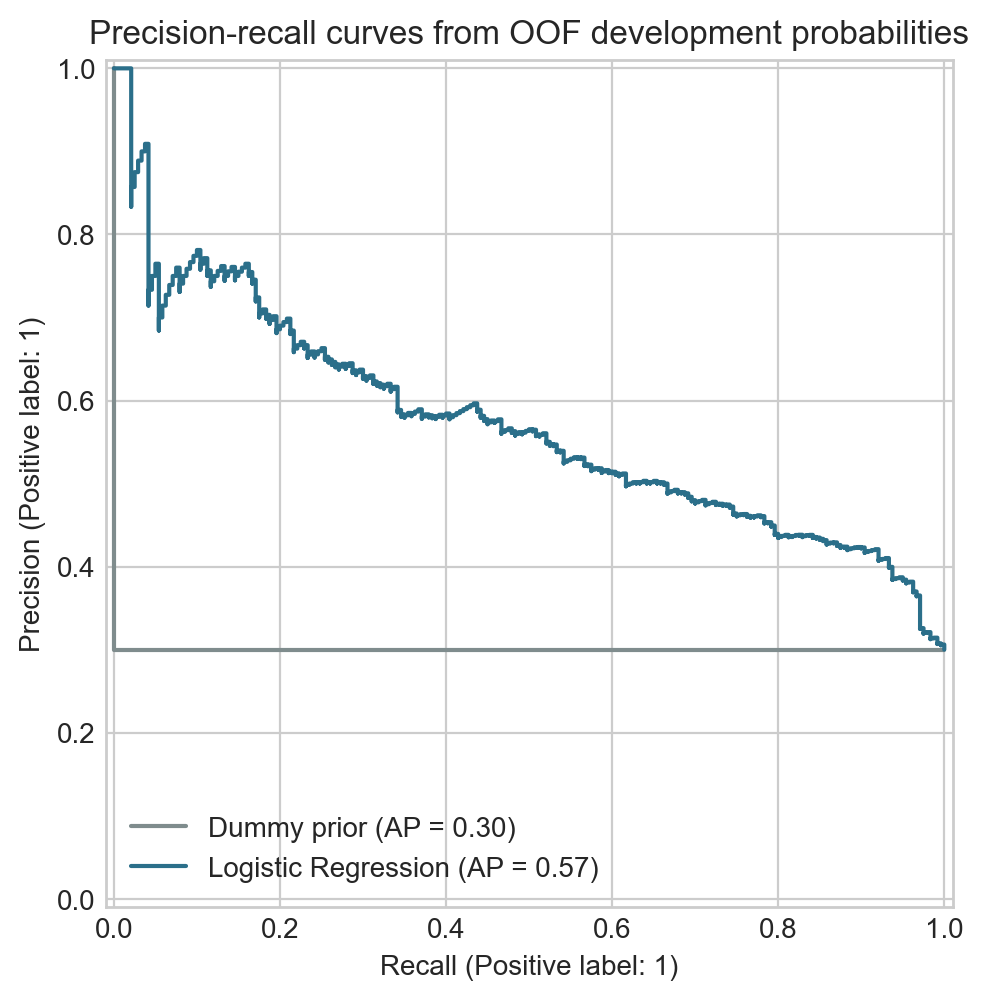

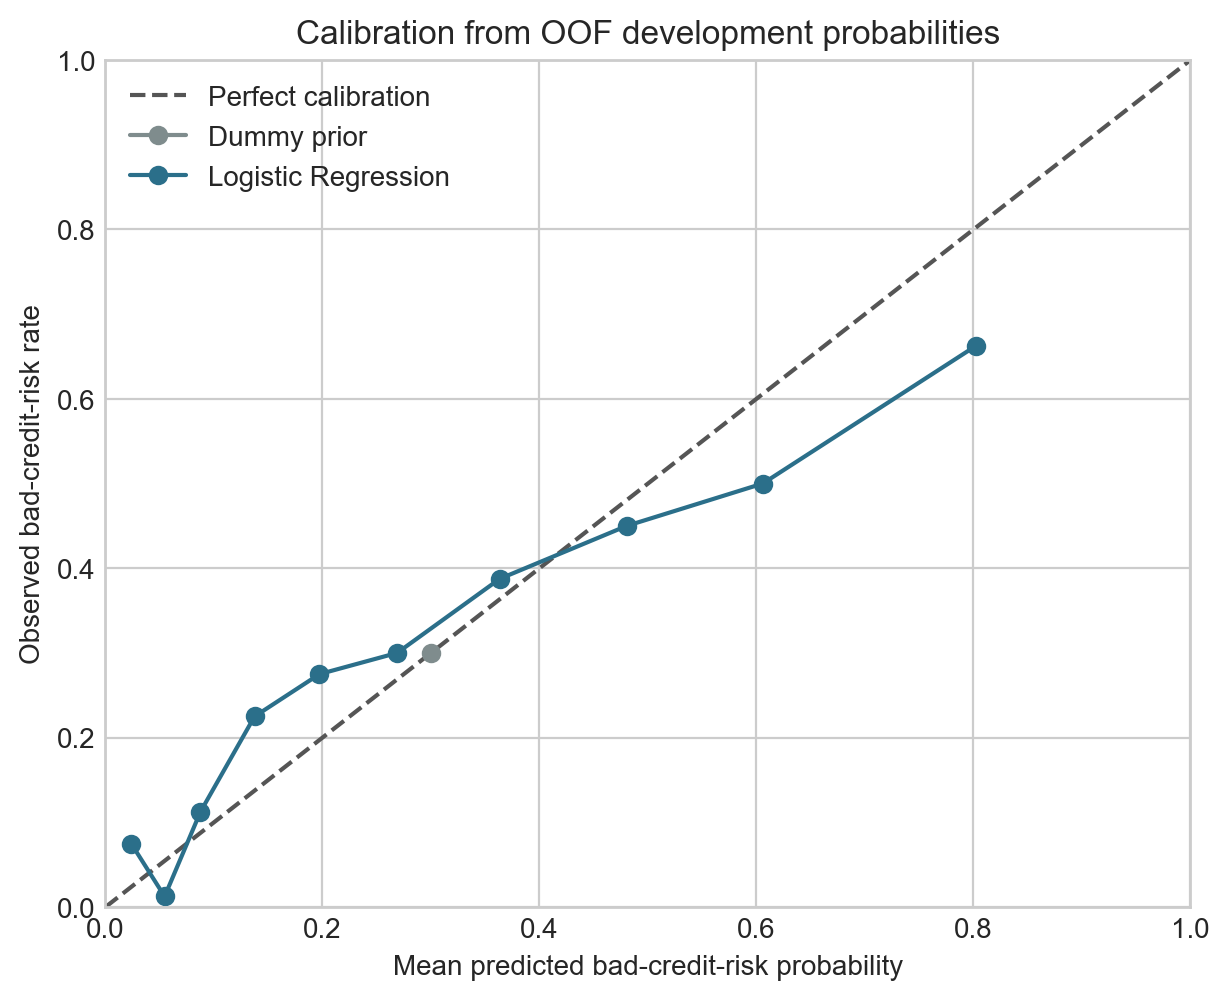

In [4]:
figure_dir = PROJECT_ROOT / 'reports/stage3_remediated/figures'
for name in ['confusion_matrices.png', 'roc_curves.png', 'precision_recall_curves.png', 'calibration.png']:
    display(Image(filename=str(figure_dir / name)))

## Coefficients and before/after comparison

The coefficient table comes from a fit on all 800 development rows only. One-hot coefficients are regularized conditional parameters, not causal effects or ordinary contrasts against a single omitted category. The comparison records changes without treating every directional movement as inherently better or worse.

In [5]:
coefficients = pd.read_csv(PROJECT_ROOT / 'reports/stage3_remediated/logistic_coefficients.csv')
comparison = pd.read_csv(PROJECT_ROOT / 'reports/stage3_remediated/original_vs_remediated.csv')
display(coefficients.head(15))
display(comparison)

,transformed_feature,source_feature,coefficient,odds_ratio_exp_coefficient,absolute_coefficient,direction_for_bad_credit_risk_score
0,categorical__purpose_A46,purpose,0.929345,2.532850,0.929345,higher
1,categorical__checking_account_status_A14,checking_account_status,-0.907385,0.403578,0.907385,lower
2,categorical__credit_history_A34,credit_history,-0.836665,0.433153,0.836665,lower
3,categorical__purpose_A41,purpose,-0.769837,0.463089,0.769837,lower
4,categorical__savings_account_status_A61,savings_account_status,0.663283,1.941155,0.663283,higher
5,categorical__savings_account_status_A64,savings_account_status,-0.635085,0.529890,0.635085,lower
6,categorical__checking_account_status_A11,checking_account_status,0.626183,1.870458,0.626183,higher
7,categorical__property_A124,property,0.619285,1.857599,0.619285,higher
8,categorical__housing_A151,housing,0.604780,1.830850,0.604780,higher
9,categorical__employment_duration_A74,employment_duration,-0.578756,0.560595,0.578756,lower


,metric,original_stage3,remediated_stage3r,absolute_difference
0,ROC-AUC,0.770112,0.762954,0.007158
1,Average Precision,0.580604,0.571027,0.009576
2,Precision for bad credit risk,0.576087,0.575269,0.000818
3,Recall for bad credit risk,0.441667,0.445833,0.004167
4,F1 for bad credit risk,0.500000,0.502347,0.002347
5,Balanced accuracy,0.651190,0.652381,0.001190
6,Brier score,0.173001,0.176217,0.003217
7,Accuracy,0.735000,0.735000,0.000000
8,False positives,78.000000,79.000000,1.000000
9,False negatives,134.000000,133.000000,1.000000


## Final-test isolation

The final 200 rows remain identified only for split integrity. No final-test probabilities, predictions, metrics, plots, preprocessing decisions, or model-selection evidence are produced. Stage 3R is the authoritative baseline for later development-only comparisons, not a production model.